# Rosenbrock100



The Rosenbrock function, also known as the Banana function, is a classical benchmark in gradient-based optimization. Its global minimum is located at $\boldsymbol{x}^*=\begin{bmatrix}
    1 & \ldots & 1
\end{bmatrix}^\top$ where the function value is zero. The minimum lies inside a parabolic shaped flat valley, which makes convergence difficult, particularly in high-dimensional settings. Note that there is also local minimums. The computational domain is defined as $\Omega=[-2,2]^d$ with $d=100$. Three fidelity levels are considered defined by 
\begin{align*}
f^{(2)}(\boldsymbol{x})&=\sum_{i=1}^{d-1}100(x_{i+1}-x_i^2)^2+(1-x_i)^2,\\
f^{(1)}(\boldsymbol{x})&=\sum_{i=1}^{d-1}50(x_{i+1}-x_i^2)^2+(-2-x_i)^2-0.5\sum_{i=1}^d x_i,\\ 
f^{(0)}(\boldsymbol{x})&=\frac{f^{(2)}(\boldsymbol{x})-4-0.5\sum_{i=1}^dx_i}{10+0.25\sum_{i=1}^dx_i},
\end{align*}
where $f^{(2)}$ is the classical Rosenbrock function. \Cref{fig:rosenbrock_illu} illustrates the three fidelities level in the two-dimensional case. The constraints considered are :
\begin{equation*}
    c_1(\boldsymbol{x})=-\sum_{i=1}^d \cos(x_i)+1\leq 0, \qquad c_2(\boldsymbol{x})=\sum_{i=1}^dx_i\leq0.
\end{equation*}


## Imports

In [1]:
import sys, os
sys.path.insert(0, os.getcwd()) #equivalent to " export PYTHONPATH="$PWD:$PYTHONPATH" "

In [2]:
from mfscbo.functions import Rosenbrock
from mfscbo.mfscbo_optimization import ScboMfOptimizer
from mfscbo.plot import plot_rhos, plot_noises, plot_bestYs, plot_nbiters, plot_tr_lengths
from mfscbo.utils import eval_fun_unnormalized
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

## Problem setup

In [3]:
# Define torch arguments
torchargs = {
    "device": "cpu",
    "dtype": torch.double
}

In [4]:
dim = 100
# Define evaluation objectives at different fidelities
f0_ = Rosenbrock(dim=dim, fidelity =1, torchargs=torchargs)
f1_ = Rosenbrock(dim=dim, fidelity =2, torchargs=torchargs)
f2_ = Rosenbrock(dim=dim, fidelity =3, torchargs=torchargs)

# Define bounds and dimension
bounds = f0_.bounds
dim = bounds.shape[1]

# Convert to maximization problem (SCBO expects maximization) and unnormalize
f0 = lambda x: -eval_fun_unnormalized(x, f0_, bounds)
f1 = lambda x: -eval_fun_unnormalized(x, f1_, bounds)
f2 = lambda x: -eval_fun_unnormalized(x, f2_, bounds)
eval_objectives = [f0, f1, f2]

In [5]:
# Define constraints (use bilog transformation for the constraints)
def constraints(x) :
    c1 = -torch.cos(x).sum(dim=1) + 1
    c2 = torch.sum(x, dim=1) - 0
    c = torch.stack([c1, c2], dim=1)
    return c

def log_constraints(x) :
    c = constraints(x)
    return torch.sign(c) * torch.log(1 + torch.abs(c))

def eval_constraints(x) :
    return eval_fun_unnormalized(x, log_constraints, bounds)


In [6]:
# Define number of initial points, rhos and costs
n_pts = [200, 40, 20]
rhos = [1, 1, 1]
costs = [1, 10, 20]

## Optimization

In [7]:
# Initialize and run the SCBO optimizer
optimizer = ScboMfOptimizer(
    eval_objectives=eval_objectives,
    constraints=eval_constraints,
    rhos=rhos,
    costs=costs,
    dim=dim,
    n_pts=n_pts,
    bounds=bounds,
    type_of_batch="parallel",
    type_of_centering="evaluated",
    torchargs=torchargs,
    restart=True,
    test=True,  # Predictive mode
)
optimizer.initialize()
optimizer.optimize(max_cost=4000, batch_size=8, path="results/Rosenbrock100", verbose=True)

Starting MF-SCBO optimization...
Max cost : 4000
Batch size : 8
Path : results/Rosenbrock100

================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================= Parameters for MF-SCBO Optimization ====================================================================================================================================================================================================================================================================================================================================

(tensor([-1.3232, -0.4893,  0.5086,  0.7894,  0.0157, -1.1364, -1.0361, -1.5360,
          0.7295, -1.3010,  1.4097,  0.4808,  1.0448,  0.3643, -0.9529, -0.3200,
         -1.5375,  1.2004, -1.6737,  1.3498,  0.5468,  1.2771, -1.2756, -0.2284,
          0.2990, -0.1457, -0.7580,  1.7578,  1.0842,  1.7772,  0.1640, -0.8655,
         -0.5991, -1.2378,  1.0701, -0.5251,  0.2204, -0.2871, -1.6820,  0.1251,
          0.0824,  0.8612,  0.5043,  0.0864, -0.5667, -0.0761, -1.2103, -0.0821,
          0.1984, -0.6389, -1.0760,  1.1155, -0.9992,  0.3398,  0.8124, -0.8437,
         -0.7135, -0.0291, -1.0076, -1.5091,  0.5832, -1.4842,  1.9307,  0.2132,
         -0.6045, -1.0495,  0.1676, -0.9718, -0.9494,  0.0782, -1.1785,  0.4071,
          0.9741,  0.4664,  0.1288, -0.5899, -1.1818, -0.3339,  0.6320, -0.2351,
         -1.1569, -1.3162, -0.3503,  1.4724,  0.1889,  0.9950, -0.9591,  1.6692,
          0.7621, -0.3057,  0.0269,  1.5570,  1.5451,  1.3008,  1.1306,  0.7209,
         -1.6224,  1.0444, -

## Post process

In [8]:
# Load results
data = np.load("results/Rosenbrock100/MFSCBO_data.npz", allow_pickle=True)
gps_info = data["gps_info"]
iterations = data["iterations"]
xvalues = data["cost_iter"]
bestY = -data["best_Y"] #for minimization plot
best_C = data["best_C"]
nbiters = data["nb_iter"]
tr_lengths = data["trust_region_lengths"]

In [9]:
# Post-process bestY when constraints are not respected 
best_violated_C = np.sum(np.maximum(0, best_C), axis=1)
bestY = np.array(bestY, dtype=np.float64)
running_max = np.max(bestY)
bestY = np.where(best_violated_C > 0, running_max, bestY)

# Post-process rhos
rhos = [[1] for _ in range(len(gps_info)-1)]  # no rho for fidelity 0
for fid in range(1, len(gps_info)):
    for it in range(len(iterations)-1):
        rhos[fid-1].append(gps_info[fid][it]["rho"])

# Post-process noises
noises = [[] for _ in range(len(gps_info))]
for fid in range(len(gps_info)):
    for it in range(len(iterations)-1):
        noises[fid].append(gps_info[fid][it]["noise"])

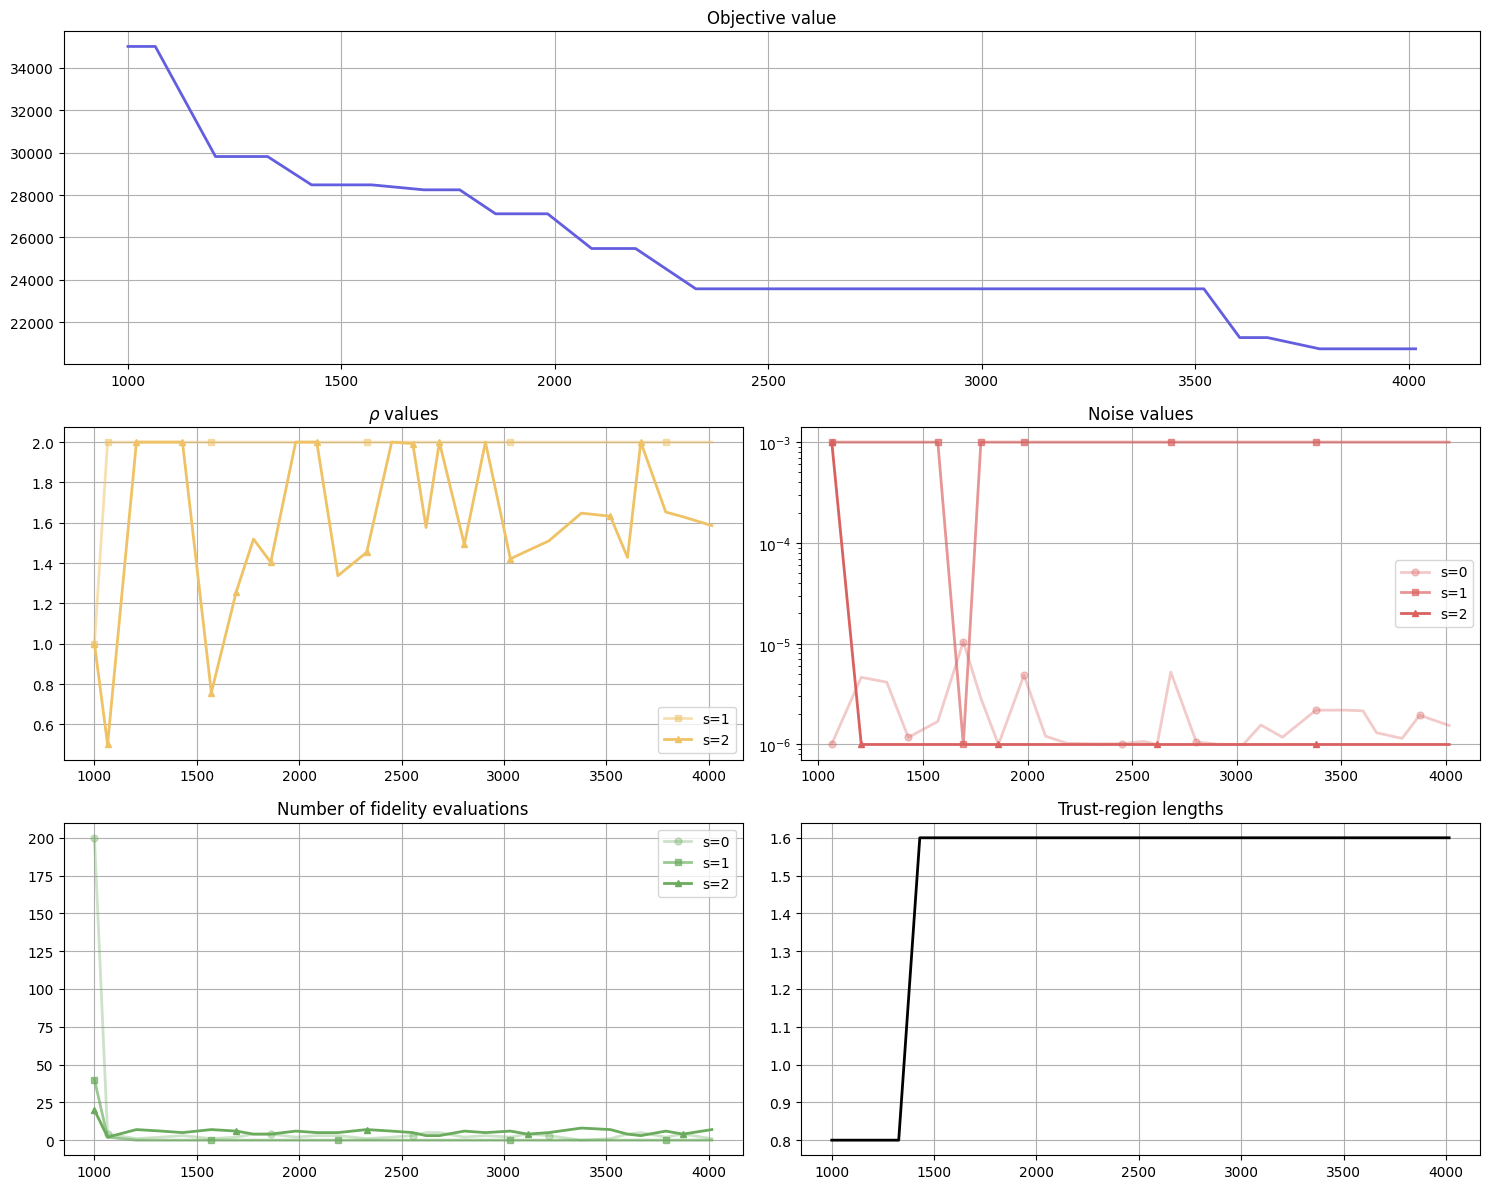

In [ ]:
# Plot results
fig = plt.figure(figsize=(15, 12))
gs = GridSpec(3, 2, figure=fig)
ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])
ax4 = fig.add_subplot(gs[2, 0])
ax5 = fig.add_subplot(gs[2, 1])

plot_bestYs(bestY, xvalues, ax=ax1)
plot_rhos(rhos, xvalues, ax=ax2)
plot_noises(noises, xvalues[1:], ax=ax3)
plot_nbiters(nbiters, xvalues, ax=ax4)
plot_tr_lengths(tr_lengths, xvalues, ax=ax5)

# Set titles, legends, and grids
ax1.set_title("Objective value")
ax1.grid()
ax2.set_title(r"$\rho$ values")
ax2.legend()
ax2.grid()
ax3.set_title("Noise values")
ax3.legend()
ax3.grid()
ax3.set_yscale("log")
ax4.set_title("Number of fidelity evaluations")
ax4.legend()
ax4.grid()
ax5.set_title("Trust-region lengths")
ax5.grid()

plt.tight_layout()
plt.savefig("results/Rosenbrock100/MFSCBO_plots.pdf")
plt.show()